# Séance 1 : Fondations Computationnelles — Python pour Mathématiciens

**Objectifs** :
- Prendre en main Python pour l'implémentation d'algorithmes mathématiques.
- Implémenter l'algorithme d'Euclide étendu et le crible d'Ératosthène.
- Mesurer et analyser la complexité algorithmique.

---

# Séance 1 : Fondations Computationnelles — Python pour Mathématiciens

**Objectifs** :
- Prendre en main Python pour l'implémentation d'algorithmes mathématiques.
- Implémenter l'algorithme d'Euclide étendu et le crible d'Ératosthène.
- Mesurer et analyser la complexité algorithmique.

---

## 1. Préparation de l'environnement

Exécutez la cellule suivante pour importer les bibliothèques nécessaires.

In [203]:
import timeit
import matplotlib.pyplot as plt
import math

%matplotlib inline

## 2. Algorithme d'Euclide étendu

### Version récursive

Rappel : l'algorithme retourne $(d, u, v)$ tel que $d = a u + b v = \mathrm{pgcd}(a,b)$.

In [204]:
def euclide_etendu_rec(a, b):
    """
    Algorithme d'Euclide étendu (version récursive).
    Retourne (pgcd, u, v) avec a*u + b*v = pgcd.
    """
    if b == 0:
        return (a, 1, 0)
    else:
        d, u1, v1 = euclide_etendu_rec(b, a % b)
        u = v1
        v = u1 - (a // b) * v1
        return (d, u, v)

In [206]:
# Test rapide
a, b = 240, 46
d, u, v = euclide_etendu_rec(a, b)
print(f"pgcd({a}, {b}) = {d}")
print(f"{a}*{u} + {b}*{v} = {a*u + b*v}")

pgcd(240, 46) = 2
240*-9 + 46*47 = 2


### Version itérative (à compléter)

**Exercice** : Implémentez ci-dessous une version itérative de l'algorithme d'Euclide étendu. Vous pouvez utiliser une boucle `while` et mettre à jour les coefficients.

In [207]:
def euclide_etendu_iter(a, b):
    """
    Version itérative de l'algorithme d'Euclide étendu.
    Retourne (pgcd, u, v) avec a*u + b*v = pgcd.
    """
    if b == 0:
        return (a, 1, 0)
    
    # Coefficients pour l'identité de Bézout
    # r = a*u + b*v
    # Initialement : a = a*1 + b*0, b = a*0 + b*1
    u0, v0 = 1, 0  # coefficients pour a
    u1, v1 = 0, 1  # coefficients pour b
    
    while b != 0:
        q = a // b
        a, b = b, a - q * b
        u0, u1 = u1, u0 - q * u1
        v0, v1 = v1, v0 - q * v1
    
    return (a, u0, v0)

In [208]:
# Test de votre version itérative
d, u, v = euclide_etendu_iter(240, 46)
assert d == 2 and 240*u + 46*v == 2
print("Test réussi !")

Test réussi !


## 3. Crible d'Ératosthène

### Version de base

In [209]:
def eratosthene(n):
    """
    Retourne la liste des nombres premiers <= n.
    """
    if n < 2:
        return [], 0
    
    ctr = 0
    est_premier = [True] * (n+1)
    est_premier[0] = est_premier[1] = False
    
    for p in range(2, int(n**0.5) + 1):
        if est_premier[p]:
            for multiple in range(p*p, n+1, p):
                est_premier[multiple] = False
                ctr += 1
    
    premiers = [i for i, prime in enumerate(est_premier) if prime]
    return premiers, ctr

In [210]:
#Test
premiers, ops = eratosthene(100)
print(f"Premiers <= 100 : {premiers}")

Premiers <= 100 : [2, 3, 5, 7, 11, 13, 17, 19, 23, 29, 31, 37, 41, 43, 47, 53, 59, 61, 67, 71, 73, 79, 83, 89, 97]


### Version optimisée (nombres impairs uniquement)

**Exercice** : Modifiez le crible pour ne traiter que les nombres impairs (sauf 2).

In [211]:
def eratosthene_opt(n):
    """
    Crible optimisé - ne traite que les nombres impairs.
    """
    if n < 2:
        return []
    if n == 2:
        return [2]
    
    taille = (n - 1) // 2
    est_premier = [True] * taille
    premiers = [2]
    
    for i in range(taille):
        if est_premier[i]:
            p = 2 * i + 3
            premiers.append(p)
            
            if p * p <= n:
                debut = (p * p - 3) // 2
                for j in range(debut, taille, p):
                    est_premier[j] = False
    
    return premiers

In [212]:
# Test
premiers_opt = eratosthene_opt(100)
print(f"Premiers <= 100 (version optimisée) : {premiers_opt}")

Premiers <= 100 (version optimisée) : [2, 3, 5, 7, 11, 13, 17, 19, 23, 29, 31, 37, 41, 43, 47, 53, 59, 61, 67, 71, 73, 79, 83, 89, 97]


## 4. Analyse de complexité empirique

Nous allons mesurer le temps d'exécution du crible pour différentes valeurs de $n$.

In [213]:
def mesurer_temps(fonction, n, repetitions=10):
    """
    Temps moyen d'exécution de fonction(n)
    """
    timer = timeit.Timer(lambda: fonction(n))
    temps = timer.timeit(number=repetitions)
    return temps / repetitions

In [202]:
valeurs_n = [10**i for i in range(3, 8)]

temps_base = []
temps_opt = []

for n in valeurs_n:
    t_base = mesurer_temps(eratosthene, n, repetitions=3)
    t_opt = mesurer_temps(eratosthene_opt, n, repetitions=3)

    temps_base.append(t_base)
    temps_opt.append(t_opt)

    print(f"n = {n:7d} : base = {t_base:.4f}s, opt = {t_opt:.4f}s")

n =    1000 : base = 0.0007s, opt = 0.0003s
n =   10000 : base = 0.0088s, opt = 0.0035s
n =  100000 : base = 0.1166s, opt = 0.0246s
n = 1000000 : base = 0.5250s, opt = 0.1673s
n = 10000000 : base = 6.2859s, opt = 2.5331s


### Visualisation

On souhaite vérifier que le temps est proportionnel à $n \log \log n$.

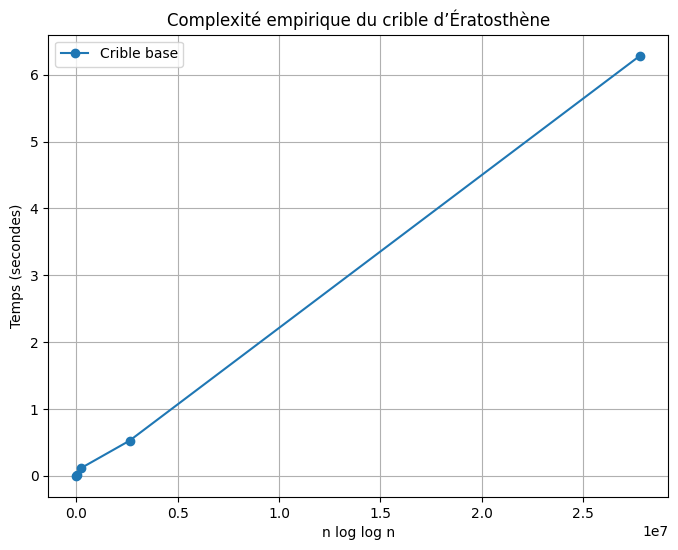

In [205]:
n_loglog = [n * math.log(math.log(n)) if n>2 else 0 for n in valeurs_n]

plt.figure(figsize=(8,6))
plt.plot(n_loglog, temps_base, 'o-', label='Crible base')
# plt.plot(n_loglog, temps_opt, 's-', label='Crible optimisé')  # à décommenter
plt.xlabel('n log log n')
plt.ylabel('Temps (secondes)')
plt.title('Complexité empirique du crible d’Ératosthène')
plt.legend()
plt.grid(True)
plt.show()

**Question** : Le graphique est-il approximativement une droite ? Que peut-on en conclure ?

## 5. Conclusion et rendu

- Assurez-vous que votre notebook contient **toutes** les fonctions demandées (versions récursive et itérative d'Euclide étendu, crible optimisé).
- Ajoutez des commentaires expliquant vos choix d'implémentation.
- Exportez ce notebook au format `.ipynb` et commitez-le dans votre dépôt GitHub.

**Rappel** : Vous pouvez utiliser l'IA comme assistant, mais vous devez comprendre chaque ligne de code et être capable de l'expliquer.